In [1]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Mufeed\Downloads\babies.csv")
df

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0
...,...,...,...,...,...,...,...,...
1231,1232,113,275.0,1,27.0,60.0,100.0,0.0
1232,1233,128,265.0,0,24.0,67.0,120.0,0.0
1233,1234,130,291.0,0,30.0,65.0,150.0,1.0
1234,1235,125,281.0,1,21.0,65.0,110.0,0.0


In [2]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='str')

In [3]:
df.drop("case",axis=1,inplace=True)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   bwt        1236 non-null   int64  
 1   gestation  1223 non-null   float64
 2   parity     1236 non-null   int64  
 3   age        1234 non-null   float64
 4   height     1214 non-null   float64
 5   weight     1200 non-null   float64
 6   smoke      1226 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 67.7 KB


In [5]:
df.describe()

,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


In [6]:
df.isnull().sum()

bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [7]:
len(df)-36

1200

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dropna(inplace=True)

In [10]:
len(df)

1174

In [11]:
import matplotlib.pyplot as plt


In [12]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='str')

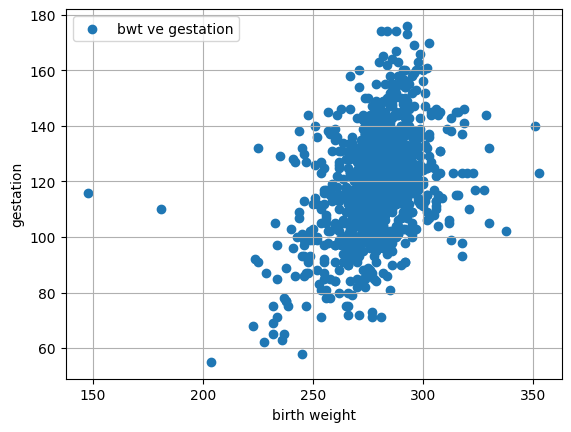

In [13]:
plt.scatter(df["gestation"],df["bwt"],label="bwt ve gestation")
plt.grid(True)
plt.xlabel("birth weight")
plt.ylabel("gestation")
plt.legend()
plt.show()

In [14]:
y=df["bwt"]
x=df.iloc[:,1:]
print(x)

      gestation  parity   age  height  weight  smoke
0         284.0       0  27.0    62.0   100.0    0.0
1         282.0       0  33.0    64.0   135.0    0.0
2         279.0       0  28.0    64.0   115.0    1.0
4         282.0       0  23.0    67.0   125.0    1.0
5         286.0       0  25.0    62.0    93.0    0.0
...         ...     ...   ...     ...     ...    ...
1231      275.0       1  27.0    60.0   100.0    0.0
1232      265.0       0  24.0    67.0   120.0    0.0
1233      291.0       0  30.0    65.0   150.0    1.0
1234      281.0       1  21.0    65.0   110.0    0.0
1235      297.0       0  38.0    65.0   129.0    0.0

[1174 rows x 6 columns]


In [15]:
from sklearn.model_selection import train_test_split as tts

In [16]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.20)

In [17]:
x_test.shape

(235, 6)

In [18]:
from sklearn.linear_model import LinearRegression,Lasso,Ridge
lr=LinearRegression()
lasso=Lasso()
ridge=Ridge()


In [19]:
lr.fit(x_train,y_train)
lasso.fit(x_train,y_train)
ridge.fit(x_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [20]:
lr_pred=lr.predict(x_test)
lasso_pred=lasso.predict(x_test)
ridge_pred=ridge.predict(x_test)


In [21]:
from sklearn.metrics import r2_score,mean_squared_error
lr_rscore=r2_score(y_test,lr_pred)
laso_rscore=r2_score(y_test,lasso_pred)
ridge_rscore=r2_score(y_test,ridge_pred)
lr_mse=mean_squared_error(y_test,lr_pred)
laso_mse=mean_squared_error(y_test,lasso_pred)
ridge_mse=mean_squared_error(y_test,ridge_pred)


In [22]:
print("model evaluation")
print(f"r2_error and mse for lr {lr_rscore},{lr_mse}")
print(f"r2_error and mse for lasso {laso_rscore},{laso_mse}")
print(f"r2_error and mse for ridge {ridge_rscore},{ridge_mse}")


model evaluation
r2_error and mse for lr 0.16027876124737217,313.50652226779255
r2_error and mse for lasso 0.15779584454950302,314.43350915713916
r2_error and mse for ridge 0.1604173983391587,313.4547626712771


In [23]:
import pickle

In [24]:
with open("pickle_model.pkl","wb") as f:
    pickle.dump(lr,f)

In [26]:
with open("pickle_model.pkl","rb") as obj:
    mymodel=pickle.load(obj)

In [27]:
print(mymodel)

LinearRegression()


In [30]:
x_test.head()

,gestation,parity,age,height,weight,smoke
296,294.0,0,34.0,59.0,105.0,0.0
250,262.0,0,38.0,59.0,110.0,1.0
408,286.0,1,22.0,64.0,140.0,0.0
571,274.0,0,23.0,66.0,135.0,0.0
211,270.0,0,25.0,62.0,150.0,0.0


In [34]:
test_data={
    'gestation':[294.0],
    'parity':[0],
    'age':[34.0],
    'height':[59.0],
    'weight':[105.0],
    'smoke':[0.0]


}

In [36]:
test_df=pd.DataFrame(test_data)

In [37]:
mymodel.predict(test_df)

array([124.76398695])